# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_squared_error, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import shap
# Import your chosen baseline model
from sklearn.ensemble import RandomForestClassifier

c:\Users\bthobor\AppData\Local\anaconda3\envs\tf310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Choice

A Random Forest is well suited as a baseline for this dataset because it handles high-dimensional, non-linear features effectively and requires minimal preprocessing of the biovolume bins. It is robust to noise, correlations, and class imbalance, and it provides interpretable feature importances. This makes it a strong, reliable reference model before exploring more complex approaches.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]

Including:
For the baseline model, all biovolume-normalized bin features (approximately 680 columns covering ESD ranges from 0.203–0.256 mm up to 8.19–10.3 mm) are used. These variables capture the full size-spectrum distribution of the plankton community and represent the core ecological signal of each profile.

Excluding:
Profile_id, because it is an identifier and provides no predictive ecological information.
cluster, because it is the target label.

This selection yields a clean baseline that leverages only meaningful biological measurements, avoids information leakage, and provides a robust point of comparison for future feature engineering.


In [46]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
df_bioVol = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')
# remove outlier profiles from dataset

list_outlier_profiles = pd.read_pickle('../Data/outlier_profiles_global_sizeclass_log.pkl')
# list of 88 profile_ids with outliers in log-space across size-classes

df_bioVol = df_bioVol[~df_bioVol['Profile_id'].isin(list_outlier_profiles)]
print(f"Removed {len(list_outlier_profiles)} outlier profiles. Cleaned dataset has {df_bioVol.shape[0]/40} profiles.")

df_bioVol.info()

df_clusters = pd.read_pickle('../Data/Profile_id_to_clusters_4_and_6.pkl') # or _v3


Removed 88 outlier profiles. Cleaned dataset has 5531.0 profiles.
<class 'pandas.core.frame.DataFrame'>
Index: 221240 entries, 0 to 224759
Data columns (total 20 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   Profile_id                                       221240 non-null  object 
 1   depth                                            221240 non-null  float64
 2   depth_bin                                        221240 non-null  int64  
 3   Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)  221240 non-null  float64
 4   Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)  221240 non-null  float64
 5   Biovolume norm [ppm mm-1] (ESD: 0.323-0.406 mm)  221240 non-null  float64
 6   Biovolume norm [ppm mm-1] (ESD: 0.406-0.512 mm)  221240 non-null  float64
 7   Biovolume norm [ppm mm-1] (ESD: 0.512-0.645 mm)  221240 non-null  float64
 8   Biovolume norm [ppm mm-1] (ESD: 0

In [ ]:

# overwrite cluster column to choose number of clusters
df_clusters['cluster'] = df_clusters['cluster_4']  # or 'cluster_6' or remove = 10 clusters

#df.info()
df_clusters.info()

# Transform the dataset into one big array
df_merged = df_bioVol.merge(df_clusters[['Profile_id', 'cluster']], 
                           on='Profile_id', 
                           how='left')

# remove outlier profiles from dataset
df_merged = df_merged[~df_merged['Profile_id'].isin(list_outlier_profiles)]
print(f"Removed {len(list_outlier_profiles)} outlier profiles. Cleaned dataset has {df_merged.shape[0]/40} profiles.")

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5619 entries, 0 to 5618
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Profile_id  5619 non-null   object
 1   cluster     5619 non-null   int32 
 2   cluster_4   5619 non-null   int32 
 3   cluster_6   5619 non-null   int32 
dtypes: int32(3), object(1)
memory usage: 109.9+ KB
Removed 88 outlier profiles. Cleaned dataset has 5531.0 profiles.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221240 entries, 0 to 221239
Data columns (total 21 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   Profile_id                                       221240 non-null  object 
 1   depth                                            221240 non-null  float64
 2   depth_bin                                        221240 non-null  int64  
 3   Biovolume norm [ppm mm-1]

In [31]:
# Transform the dataset, so that we have one row per profile_id. depth and Biovolume data are merged into columns with Biovolume_1_depth_1 etc
# 1. Biovolumen-Spalten identifizieren
biovol_cols = [c for c in df_bioVol.columns 
               if c.startswith("Biovolume norm")]

# 2. Pivotieren: jede Profile_id -> eine Zeile
df_pivot = df_bioVol.pivot_table(
    index="Profile_id",
    columns="depth_bin",
    values=biovol_cols
)

# 3. Spalten umbenennen zu flachen Namen
df_pivot.columns = [
    f"{col[0]}_bin{col[1]}"
    for col in df_pivot.columns.to_flat_index()
]

df_pivot = df_pivot.reset_index()
df_final = df_pivot.merge(df_clusters, on="Profile_id", how="left")
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Columns: 684 entries, Profile_id to cluster_6
dtypes: float64(680), int32(3), object(1)
memory usage: 28.8+ MB


### Normalize data
- We are interested primarily in the distribution of Biovolume and not the absolute magnitude differences between profiles. Therefore, we normalize Biovolume per profile so that values for every Profile_id are between 0 and 1.

In [32]:
# Normalization of Data
import pandas as pd

df_norm = df_final.copy()

# Nicht-numerische Spalten (z. B. Profile_id, cluster) trennen
non_numeric = ['Profile_id', 'cluster']   # ggf. anpassen
numeric_cols = df_final.columns.difference(non_numeric)

# Zeilenweise Normalisierung auf numerische Spalten
df_norm[numeric_cols] = df_final[numeric_cols].sub(df_final[numeric_cols].min(axis=1), axis=0)
df_norm[numeric_cols] = df_norm[numeric_cols].div(
    df_final[numeric_cols].max(axis=1) - df_final[numeric_cols].min(axis=1),
    axis=0
)

df_norm.head()

df_final = df_norm


In [36]:
# Splitting the dataset
# in notebook "train-test-val-split.ipynb" we assigned each Profile_is to train/test
split_mapping = pd.read_pickle('../Data/Profile_id_to_train_test_cross_val_v2.pkl')
split_mapping.info()

df_final = df_final.merge(split_mapping, on="Profile_id", how="left")
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5619 entries, 0 to 5618
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Profile_id  5619 non-null   object
 1   data_type   5619 non-null   object
 2   CV_fold     5619 non-null   object
dtypes: object(3)
memory usage: 131.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Columns: 690 entries, Profile_id to CV_fold
dtypes: float64(682), int32(1), object(7)
memory usage: 29.1+ MB


Number of profiles in training set: 4149
Number of profiles in test set: 1382


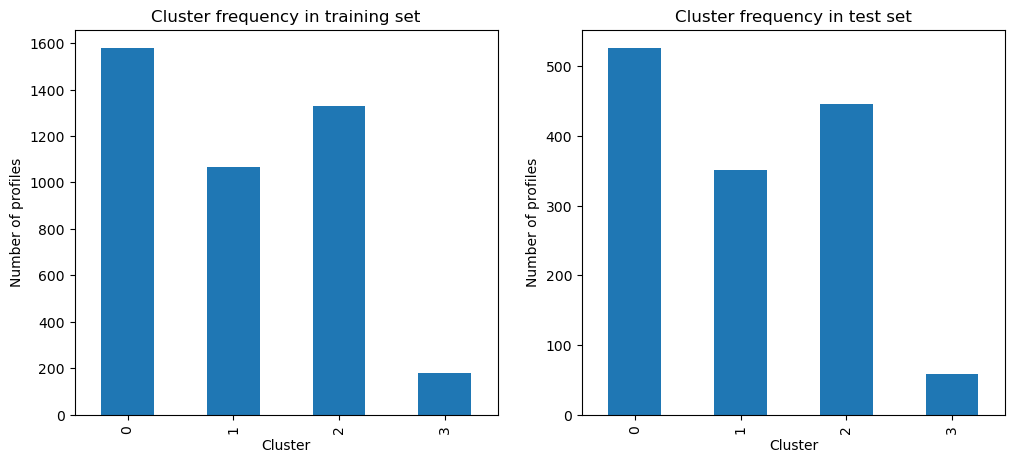

In [37]:

# Feature selection
# Example: Selecting only two features for a simple baseline model
# select columns as features
biovol_cols = [c for c in df_final.columns 
               if c.startswith("Biovolume norm")]
X = df_final[biovol_cols]
y = df_final['cluster']

train_mask = df_final['data_type'] == 'train'
test_mask = df_final['data_type'] == 'test'

# add CV_col to X_train until balancing is done
X_train = df_final.loc[train_mask, biovol_cols + ['CV_fold']].reset_index(drop=True).copy()
y_train = df_final.loc[train_mask, 'cluster'].reset_index(drop=True).copy()

X_test = df_final.loc[test_mask, biovol_cols].reset_index(drop=True).copy()
y_test = df_final.loc[test_mask, 'cluster'].reset_index(drop=True).copy()

# print number of profiles in train and test
print(f"Number of profiles in training set: {X_train.shape[0]}")
print(f"Number of profiles in test set: {X_test.shape[0]}")

# plot cluster-frequency in train and test
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
y_train.value_counts().sort_index().plot(kind='bar')
plt.title('Cluster frequency in training set')
plt.xlabel('Cluster')
plt.ylabel('Number of profiles')
plt.subplot(1,2,2)
y_test.value_counts().sort_index().plot(kind='bar')
plt.title('Cluster frequency in test set')
plt.xlabel('Cluster')
plt.ylabel('Number of profiles')
plt.show()

for training set, ~450 profiles seems to be a good fit to over/undersample (~5 clusters above & 5 clusters below)

In [38]:

# -----------------------------------------
# Balancing: jedes Cluster genau 450-mal im Trainingssatz
# -----------------------------------------

train_df = X_train.copy()
train_df["cluster"] = y_train.values

# target_n should be the mean of samples per cluster
target_n = len(train_df) // train_df["cluster"].nunique()  # gewünschte Anzahl pro Cluster = ~ n(training set) / n(clusters)
balanced_groups = []

for label, group in train_df.groupby("cluster"):
    if len(group) > target_n:
        # Zu viele Samples → auf 450 reduzieren
        sampled = group.sample(n=target_n, random_state=42)
    elif len(group) < target_n:
        # Zu wenige Samples → mit Zurücklegen auf 600 auffüllen
        sampled = group.sample(n=target_n, replace=True, random_state=42)
    else:
        sampled = group
    balanced_groups.append(sampled)

balanced_df = pd.concat(balanced_groups)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = balanced_df.drop(columns="cluster")
y_train_balanced = balanced_df["cluster"]

print("distribution before:")
print(y_train.value_counts())
print("\ndistribution after:")
print(y_train_balanced.value_counts())

# -----------------------------------------
# Ab hier nimmst du für das Modell:
# X_train_balanced, y_train_balanced
# und zum Testen weiterhin: X_test, y_test
# -----------------------------------------
#############

# save CV_fold - index mapping to separate df
cv_fold_train = X_train_balanced[['CV_fold']].copy()

# remove CV_fold from X_train_balanced
X_train_balanced = X_train_balanced.drop(columns=['CV_fold'])


distribution before:
cluster
0    1578
2    1328
1    1065
3     178
Name: count, dtype: int64

distribution after:
cluster
0    1037
1    1037
3    1037
2    1037
Name: count, dtype: int64


In [39]:
X_train_balanced.info()
print("==============================")
y_train_balanced.info()
print("==============================")
cv_fold_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4148 entries, 0 to 4147
Columns: 680 entries, Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin0 to Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin39
dtypes: float64(680)
memory usage: 21.5 MB
<class 'pandas.core.series.Series'>
RangeIndex: 4148 entries, 0 to 4147
Series name: cluster
Non-Null Count  Dtype
--------------  -----
4148 non-null   int32
dtypes: int32(1)
memory usage: 16.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4148 entries, 0 to 4147
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CV_fold  4148 non-null   object
dtypes: object(1)
memory usage: 32.5+ KB


## Implementation

- uses RandomForestClassifier with cross-validation using four pre-defined folds

In [40]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import PredefinedSplit, cross_validate

# ---------- CONFIG ----------
rf_params = {'n_estimators': 500, 'random_state': 42, 'class_weight': 'balanced', 'n_jobs': -1}
scoring = ['accuracy', 'balanced_accuracy', 'f1_macro']
# ----------------------------

# Assume these three objects exist in the notebook:
# - X_train_balanced : pd.DataFrame (4500 x 680)
# - y_train_balanced : pd.Series (4500,)
# - cv_fold_train    : pd.DataFrame or pd.Series with one column 'CV_fold' (4500,)

# 1) Coerce inputs to simple pandas objects
X = X_train_balanced.reset_index(drop=True) if isinstance(X_train_balanced, pd.DataFrame) else pd.DataFrame(X_train_balanced)
y = pd.Series(y_train_balanced).reset_index(drop=True)

# cv_fold_train may be a DataFrame (one column) or a Series — convert to 1D Series of strings
if isinstance(cv_fold_train, pd.DataFrame):
    if cv_fold_train.shape[1] != 1:
        raise RuntimeError("cv_fold_train must have exactly one column of fold labels.")
    cv = cv_fold_train.iloc[:, 0].astype(str).reset_index(drop=True)
else:
    cv = pd.Series(cv_fold_train).astype(str).reset_index(drop=True)

# 2) Basic length check
if not (len(X) == len(y) == len(cv)):
    raise RuntimeError(f"Length mismatch: len(X)={len(X)}, len(y)={len(y)}, len(cv)={len(cv)}")

# 3) Convert fold labels to integer indices (preserve appearance order)
test_fold = pd.factorize(cv)[0]   # returns ints 0..K-1 in order of first appearance
n_folds = len(np.unique(test_fold))
if n_folds < 2:
    raise RuntimeError("Need at least 2 unique folds in cv_fold_train.")

print(f"Using {n_folds} predefined folds. Per-fold counts:\n{dict(zip(*np.unique(test_fold, return_counts=True)))}")

# 4) PredefinedSplit and cross-validated scoring (re-trains per fold)
ps = PredefinedSplit(test_fold=test_fold)
rf_cv = RandomForestClassifier(**rf_params)

print("\nRunning cross_validate (retraining per fold using the predefined folds)...")
cv_results = cross_validate(rf_cv, X, y, cv=ps, scoring=scoring, n_jobs=-1, return_train_score=False)

# 5) Print per-fold metrics and means
print("\nCross-validation results:")
for metric in scoring:
    arr = cv_results[f'test_{metric}']
    print(f"  {metric}: per-fold={np.round(arr,4).tolist()}, mean={arr.mean():.4f}, std={arr.std():.4f}")

# 6) Train final model on the entire balanced training set
print("\nTraining final RandomForest on the full balanced training set...")
rf_final = RandomForestClassifier(**rf_params)
rf_final.fit(X, y)
print("Done — rf_final trained.")

# 7) Compute training-set metrics for the final model
y_pred_train = rf_final.predict(X)
train_acc = accuracy_score(y, y_pred_train)
train_bacc = balanced_accuracy_score(y, y_pred_train)
train_f1 = f1_score(y, y_pred_train, average='macro', zero_division=0)

train_metrics = {
    'accuracy': float(train_acc),
    'balanced_accuracy': float(train_bacc),
    'f1_macro': float(train_f1)
}

print("\nTraining-set metrics (final model):")
for k, v in train_metrics.items():
    print(f"  {k}: {v:.4f}")

# Expose useful objects for later use
cv_predefinedsplit = ps
cv_results_summary = cv_results
final_model = rf_final
cv_fold_train_aligned = cv  # 1-D Series aligned with X/y
train_metrics_summary = train_metrics

Using 4 predefined folds. Per-fold counts:
{np.int64(0): np.int64(1067), np.int64(1): np.int64(989), np.int64(2): np.int64(1051), np.int64(3): np.int64(1041)}

Running cross_validate (retraining per fold using the predefined folds)...

Cross-validation results:
  accuracy: per-fold=[0.7563, 0.7432, 0.7174, 0.7426], mean=0.7399, std=0.0141
  balanced_accuracy: per-fold=[0.7569, 0.7391, 0.7222, 0.7426], mean=0.7402, std=0.0123
  f1_macro: per-fold=[0.7595, 0.7463, 0.7209, 0.7425], mean=0.7423, std=0.0139

Training final RandomForest on the full balanced training set...
Done — rf_final trained.

Training-set metrics (final model):
  accuracy: 0.9998
  balanced_accuracy: 0.9998
  f1_macro: 0.9998


In [41]:
# Auf dem (unveränderten) Testset vorhersagen 
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
# Predict on test set
y_pred = rf_final.predict(X_test)

# Prepare y_test for evaluation
y_eval = y_test
y_eval_ser = pd.Series(y_eval).reset_index(drop=True)

# Compute metrics (matching CV metrics)
acc = accuracy_score(y_eval_ser, y_pred)
bacc = balanced_accuracy_score(y_eval_ser, y_pred)
f1m = f1_score(y_eval_ser, y_pred, average='macro', zero_division=0)
prec_m = precision_score(y_eval_ser, y_pred, average='macro', zero_division=0)
rec_m = recall_score(y_eval_ser, y_pred, average='macro', zero_division=0)

print("Test set metrics:")
print(f"  Accuracy           : {acc:.4f}")
print(f"  Balanced Accuracy  : {bacc:.4f}")
print(f"  F1 (macro)         : {f1m:.4f}")

print("\nClassification report (per-class):")
print(classification_report(y_eval_ser, y_pred, zero_division=0))

Test set metrics:
  Accuracy           : 0.7808
  Balanced Accuracy  : 0.7424
  F1 (macro)         : 0.7503

Classification report (per-class):
              precision    recall  f1-score   support

           0       0.86      0.79      0.83       526
           1       0.63      0.70      0.66       351
           2       0.83      0.85      0.84       446
           3       0.73      0.63      0.67        59

    accuracy                           0.78      1382
   macro avg       0.76      0.74      0.75      1382
weighted avg       0.79      0.78      0.78      1382



## Evaluation
To assess the baseline model’s performance and establish reference values for more complex models later on, following metrics are used:

**Accuracy**: Measures the overall proportion of correct predictions. Useful for a general performance overview, but limited when class imbalance is present. 

**Balanced Accuracy**: Computes the average accuracy across all classes, giving equal weight to minority and majority classes.
This metric is essential because the cluster distribution is imbalanced.

**Macro F1 Score**: Averages the F1-score across all classes without weighting by class frequency.
This provides a balanced view of precision and recall for each cluster, including minority groups.

#### More detailed evaluation:
**Confusion Matrix**: Visualizes how often each cluster is correctly and incorrectly classified. Helps detect systematic misclassification patterns between clusters.

**Classification Report**: Summarizes precision, recall, and F1-score for each class individually. 
Supports detailed assessment of classes that are harder to separate.

**SHAP (SHapley Additive exPlanations)**: Provides model-agnostic feature-attribution scores that show how much each feature contributes to a prediction.
SHAP was used to: interpret global feature importance and analyze feature effects for each cluster.



# SHAP feature importance


=== Train Metrics ===
Accuracy:           0.9997589199614272
Balanced Accuracy:  0.9997589199614272
Macro F1:           0.9997589199053812

=== Test Metrics ===
Accuracy:           0.7807525325615051
Balanced Accuracy:  0.7423942332276271
Macro F1:           0.7502693231292044

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.86      0.79      0.83       526
           1       0.63      0.70      0.66       351
           2       0.83      0.85      0.84       446
           3       0.73      0.63      0.67        59

    accuracy                           0.78      1382
   macro avg       0.76      0.74      0.75      1382
weighted avg       0.79      0.78      0.78      1382


=== Confusion Matrix (Test) ===
[[418  78  29   1]
 [ 55 245  41  10]
 [ 10  54 379   3]
 [  1  11  10  37]]

=== Top 20 Most Important Features ===
                                              Feature  Importance
Biovolume norm [ppm mm-1] (ESD: 

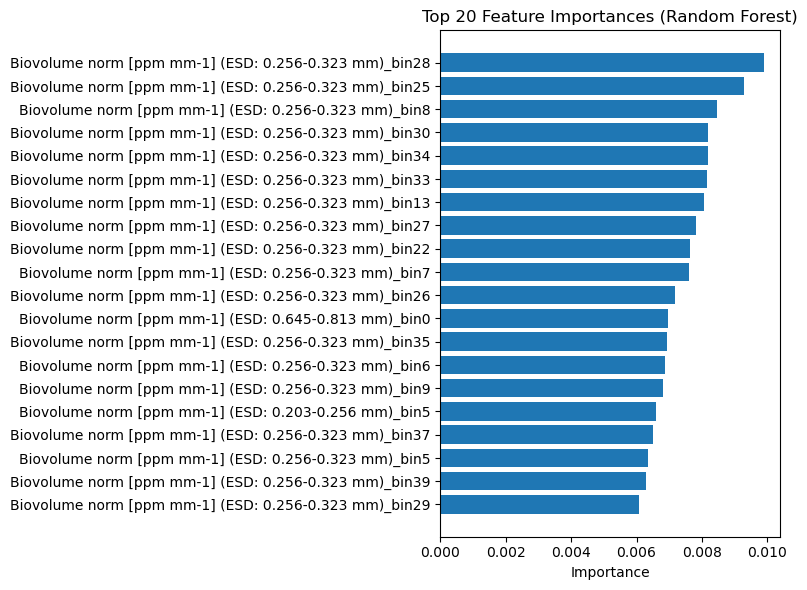

X_test_sample shape: (300, 680)
shap_values shape: (300, 680, 4)

=== SHAP Summary Plot for Class 0 ===


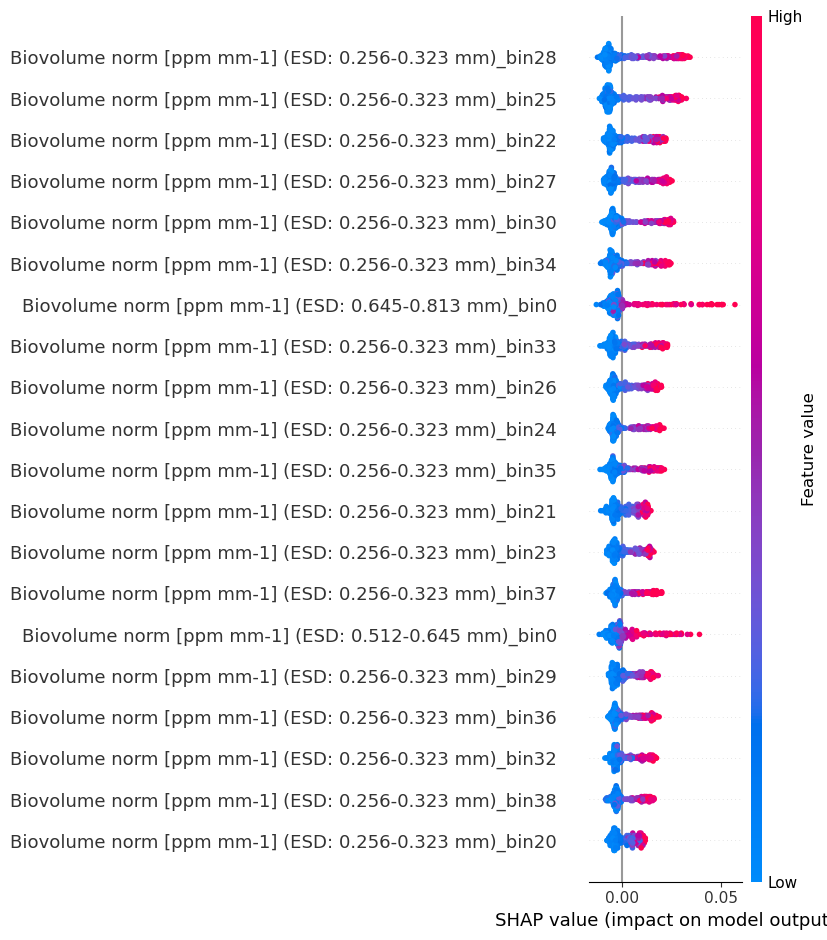


=== SHAP Summary Plot for Class 1 ===


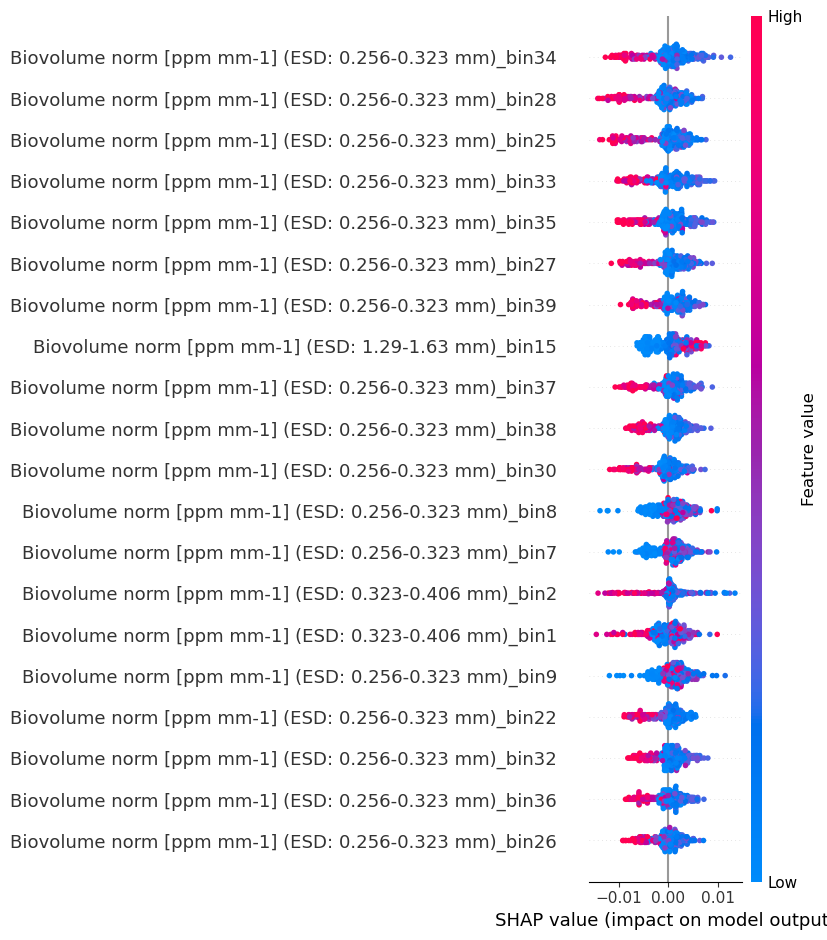


=== SHAP Summary Plot for Class 2 ===


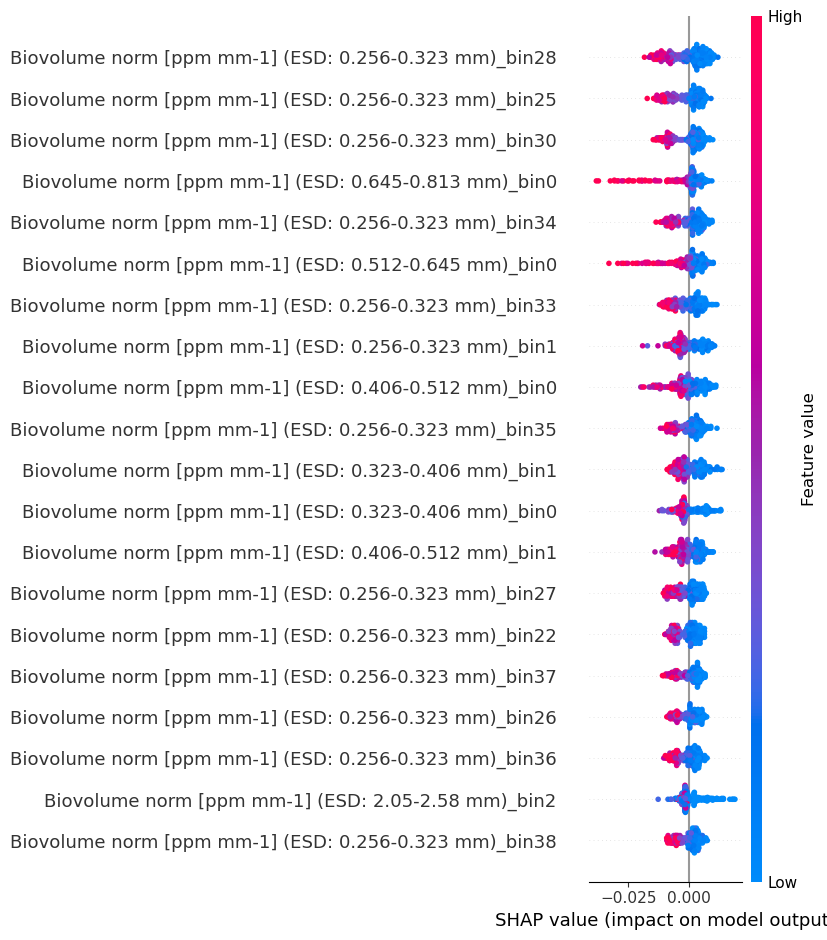


=== SHAP Summary Plot for Class 3 ===


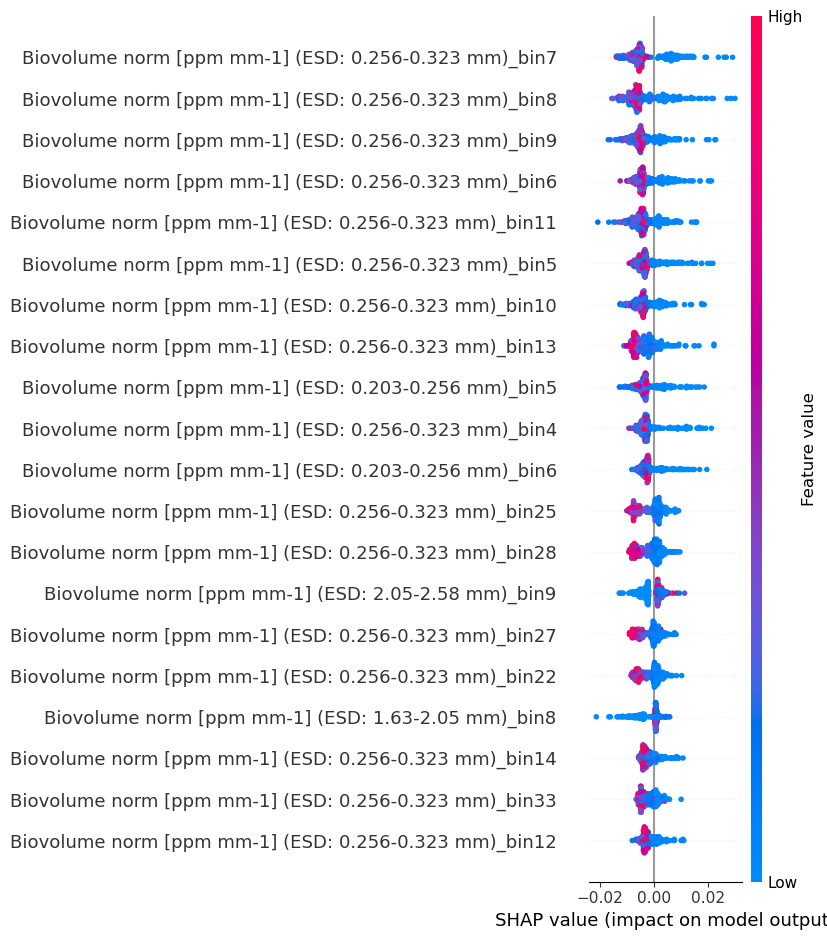


=== Top 20 Global SHAP Feature Importances ===
                                              Feature  MeanAbsSHAP
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin28     0.006047
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin25     0.005811
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin34     0.004705
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin27     0.004674
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin30     0.004662
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin33     0.004620
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin22     0.004483
 Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin8     0.004334
 Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin7     0.004151
 Biovolume norm [ppm mm-1] (ESD: 0.645-0.813 mm)_bin0     0.004080
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin35     0.003986
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin26     0.003889
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin13     0.003660
 Biovolume nor

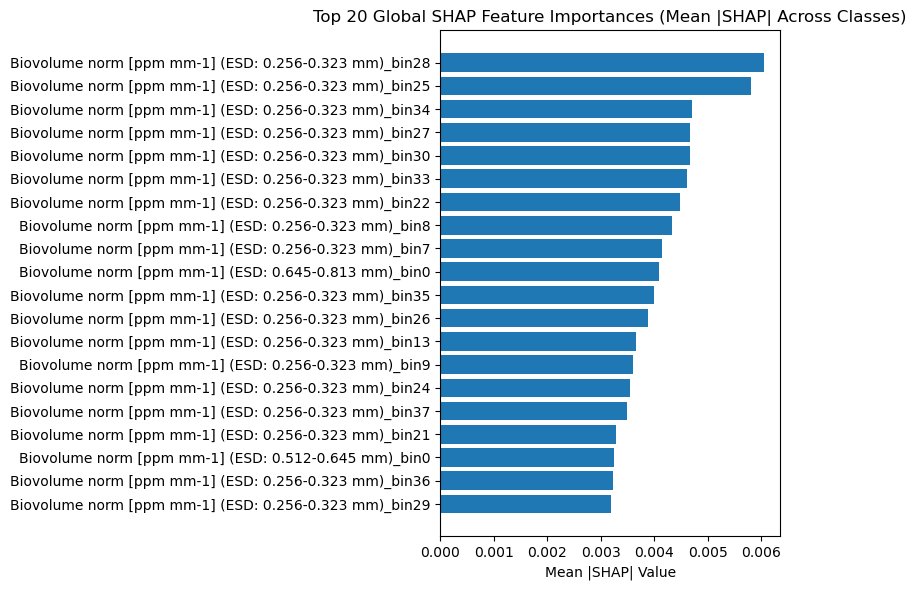

In [42]:
# -------------------------------
# Predictions on train and test data
# -------------------------------
rf = rf_final
y_pred_train = rf.predict(X_train_balanced)
y_pred_test  = rf.predict(X_test)

# -------------------------------
# Helper function to print metrics
# -------------------------------
def print_metrics(name, y_true, y_pred):
    print(f"\n=== {name} Metrics ===")
    print("Accuracy:          ", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy: ", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:          ", f1_score(y_true, y_pred, average='macro'))

# -------------------------------
# Train–test comparison
# -------------------------------
print_metrics("Train", y_train_balanced, y_pred_train)
print_metrics("Test",  y_test,          y_pred_test)

# -------------------------------
# Detailed evaluation (Test set only)
# -------------------------------
print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred_test, zero_division=0))

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_pred_test))

# -------------------------------
# Feature importance extraction
# -------------------------------
importances = rf.feature_importances_
feature_names = X_train_balanced.columns

feat_imp = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
      .sort_values(by="Importance", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Top 20 Most Important Features ===")
print(feat_imp.head(20).to_string(index=False))

# Optional: bar plot of top 20 feature importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(feat_imp["Feature"].head(top_n)[::-1],
         feat_imp["Importance"].head(top_n)[::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# =====================================================
# SHAP analysis (model explainability)
# =====================================================

#shap.initjs()

# Create explainer
explainer = shap.TreeExplainer(rf)

# Use a subset of the test data for speed
X_test_sample = X_test.sample(n=min(300, len(X_test)), random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)
shap_values = np.array(shap_values)   # expected shape: (n_samples, n_features, n_classes)

print("X_test_sample shape:", X_test_sample.shape)
print("shap_values shape:", shap_values.shape)

n_samples, n_features = X_test_sample.shape
_, sv_features, n_classes = shap_values.shape

assert sv_features == n_features, "Mismatch between SHAP feature dimension and X_test_sample"

# ---------------------------------------
# A: SHAP summary plot per class
# ---------------------------------------
for class_idx in range(n_classes):
    print(f"\n=== SHAP Summary Plot for Class {class_idx} ===")
    # shap_values for this class: (n_samples, n_features)
    sv_class = shap_values[:, :, class_idx]
    shap.summary_plot(sv_class, X_test_sample)

# ---------------------------------------
# B: Global SHAP importance across all classes
# ---------------------------------------
# Mean absolute SHAP over samples and classes -> (n_features,)
mean_abs_shap_per_feature = np.abs(shap_values).mean(axis=(0, 2))

shap_importance_df = (
    pd.DataFrame({
        "Feature": X_test_sample.columns,
        "MeanAbsSHAP": mean_abs_shap_per_feature
    })
    .sort_values("MeanAbsSHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Top 20 Global SHAP Feature Importances ===")
print(shap_importance_df.head(20).to_string(index=False))

# Optional bar plot of global SHAP importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(shap_importance_df["Feature"].head(top_n)[::-1],
         shap_importance_df["MeanAbsSHAP"].head(top_n)[::-1])
plt.title("Top 20 Global SHAP Feature Importances (Mean |SHAP| Across Classes)")
plt.xlabel("Mean |SHAP| Value")
plt.tight_layout()
plt.show()
    


# Confusion matrix heatmap

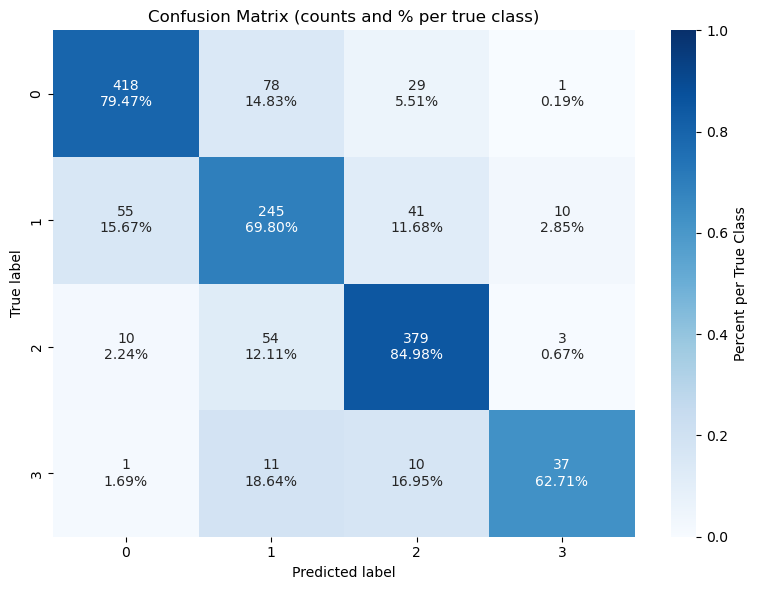

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------
# Compute confusion matrix
# -----------------------
cm = confusion_matrix(y_test, y_pred_test)

# try to get class names from the model, fallback to unique labels from data
class_names = getattr(rf_final, "classes_", None)
if class_names is None:
    class_names = np.unique(np.concatenate([y_test, y_pred_test]))
class_names = [str(c) for c in class_names]

# -----------------------
# Calculate percent per true class (row-wise normalization)
# -----------------------
row_sums = cm.sum(axis=1)[:, np.newaxis]
with np.errstate(divide='ignore', invalid='ignore'):
    cm_pct = np.divide(cm, row_sums, where=row_sums != 0)
cm_pct = np.nan_to_num(cm_pct)

# -----------------------
# Combined counts + percent annotation
# -----------------------
annot = np.empty_like(cm).astype(object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.2%}"

# -----------------------
# Plot heatmap with colors representing percentages
# -----------------------
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pct,                    # ← CHANGED: Use cm_pct for colors
            annot=annot,               # Still show counts + percentages
            fmt='',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True,
            vmin=0,                    # ← ADDED: Scale from 0%
            vmax=1,                    # ← ADDED: Scale to 100%
            cbar_kws={'label': 'Percent per True Class'})  # ← ADDED: Label colorbar

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (counts and % per true class)')
plt.tight_layout()
plt.show()

# Optional: save the last figure
# plt.savefig('confusion_matrix_annotated.png', dpi=300, bbox_inches='tight')

# Feature importance heatmap

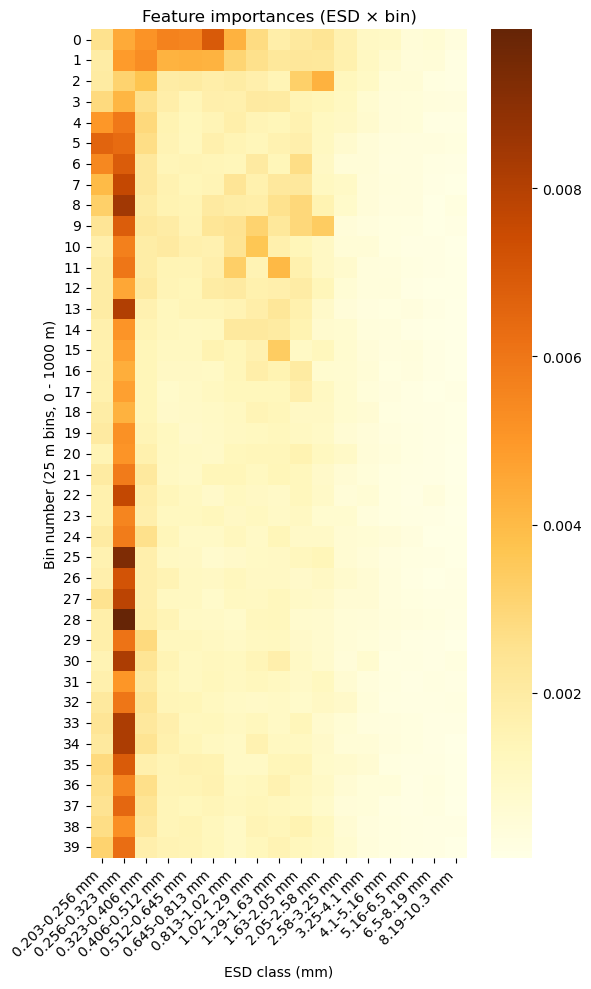

In [44]:
"""
Auto-detect feature names from a sklearn model (or a DataFrame) and plot a
grid heatmap of feature importances organised by ESD class (x axis) and bin
number (y axis).

Behavior:
- Tries to detect feature names and importances from (in order):
    1) feat_imp_df: a DataFrame you pass which has one column with feature
       strings and one with importance values (e.g. your shap_importance_df).
    2) A fitted sklearn estimator `model` that has `.feature_importances_` and
       either `.feature_names_in_` (sklearn >=1.0) or you pass `X` to get
       X.columns.
- Parses feature strings of the form:
    "...(ESD: 0.203-0.256 mm)_bin3"
  and extracts esd_min, esd_max, and bin index.
- Builds a full grid with `n_esd` columns and `n_bins` rows (defaults to
  17 and 40). Rows/cols that don't have values in the features will be filled
  with `fill_value` (default np.nan).
- Plots a seaborn heatmap with options for annotation, normalization, colormap.

Example usage:
    # If you already have a DataFrame with columns "Feature" and "MeanAbsSHAP":
    plot_feature_grid_from_features(
        feat_imp_df=shap_importance_df,
        feature_col="Feature",
        importance_col="MeanAbsSHAP",
        n_esd=17,
        n_bins=40,
    )

    # Or use the trained random forest `rf` and X_train/X_test to get names:
    plot_feature_grid_from_model(
        model=rf,
        X=X_train_balanced,  # used only to get feature names if model lacks them
        n_esd=17,
        n_bins=40,
    )
"""
from typing import Optional, Sequence, Tuple
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Flexible regex to capture ESD ranges and bin number at the end of the feature
# Example matches:
#   "... (ESD: 0.203-0.256 mm)_bin3"
#   "...(ESD:0.203-0.256 mm)_bin12"
# Also tolerates small variations in spacing and case.
_FEATURE_RE = re.compile(
    r"\(ESD\s*:\s*([0-9]*\.?[0-9]+)\s*-\s*([0-9]*\.?[0-9]+)\s*mm\).*_bin\s*([0-9]+)\s*$",
    flags=re.IGNORECASE,
)


def _parse_feature_name(fname: str) -> Tuple[Optional[float], Optional[float], Optional[int], Optional[str]]:
    """Return (esd_min, esd_max, bin_idx, esd_label) or (None, None, None, None)."""
    if not isinstance(fname, str):
        return (None, None, None, None)
    m = _FEATURE_RE.search(fname)
    if not m:
        return (None, None, None, None)
    esd_min = float(m.group(1))
    esd_max = float(m.group(2))
    bin_idx = int(m.group(3))
    esd_label = f"{esd_min:g}-{esd_max:g} mm"
    return (esd_min, esd_max, bin_idx, esd_label)


def _build_feature_dataframe_from_model(
    model,
    X: Optional[pd.DataFrame] = None,
    feature_col_name: str = "Feature",
    importance_col_name: str = "Importance",
) -> pd.DataFrame:
    """
    Try to create a DataFrame with columns [feature_col_name, importance_col_name]
    from a sklearn-like model and/or an X DataFrame.
    """
    # Case 1: model provides feature_importances_
    if hasattr(model, "feature_importances_"):
        importances = np.array(model.feature_importances_)
        # feature names prefer model.feature_names_in_ if present
        if hasattr(model, "feature_names_in_"):
            feature_names = list(model.feature_names_in_)
        elif X is not None and hasattr(X, "columns"):
            feature_names = list(X.columns)
        else:
            # fallback: create generic names
            feature_names = [f"f{i}" for i in range(len(importances))]
            warnings.warn("Couldn't detect feature names from model or X; using f0..fN.")
        if len(feature_names) != len(importances):
            raise ValueError("Length mismatch: number of feature names != number of importances")
        df = pd.DataFrame({feature_col_name: feature_names, importance_col_name: importances})
        return df

    raise ValueError("Provided model does not have feature_importances_. Pass feat_imp_df instead.")


def plot_feature_grid_from_features(
    feat_imp_df: pd.DataFrame,
    feature_col: str = "Feature",
    importance_col: str = "Importance",
    n_esd: int = 17,
    n_bins: int = 40,
    esd_sort_by: str = "min",  # "min" or "mid"
    fill_value: Optional[float] = np.nan,
    annotate: bool = True,
    annot_fmt: str = ".3f",
    figsize: Tuple[int, int] = (6, 10),
    cmap: str = "viridis",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    normalize: Optional[str] = None,  # None, 'col', 'row', 'global'
    title: Optional[str] = None,
) -> pd.DataFrame:
    """
    Build pivot and plot heatmap from a DataFrame of features/importances.

    Returns the pivot DataFrame (index=bins, columns=esd_labels).

    Parameters
    ----------
    feat_imp_df : pd.DataFrame
      DataFrame containing feature names and importance values.
    feature_col, importance_col : str
      Column names in feat_imp_df.
    n_esd, n_bins : int
      Expected grid size (used to set full grid reindexing). If parsed ESD classes
      differ from n_esd a warning is shown but plotting still proceeds with parsed labels.
    esd_sort_by : 'min' or 'mid'
      How to order ESD columns.
    fill_value : float or np.nan
      Value used for missing cells (default np.nan).
    normalize : None | 'col' | 'row' | 'global'
      If 'col', each column is scaled to sum 1; if 'row', rows sum to 1; if 'global',
      values scaled by overall max.
    """
    if feature_col not in feat_imp_df.columns or importance_col not in feat_imp_df.columns:
        raise ValueError(f"feat_imp_df must contain columns '{feature_col}' and '{importance_col}'")

    df = feat_imp_df.copy().reset_index(drop=True)
    parsed = df[feature_col].apply(_parse_feature_name)
    df["esd_min"] = parsed.apply(lambda x: x[0])
    df["esd_max"] = parsed.apply(lambda x: x[1])
    df["bin"] = parsed.apply(lambda x: x[2])
    df["esd_label"] = parsed.apply(lambda x: x[3])

    n_total = len(df)
    n_parsed = df["esd_label"].notna().sum()
    if n_parsed != n_total:
        warnings.warn(f"{n_total - n_parsed} feature(s) couldn't be parsed and will be ignored in the grid.")

    df = df.loc[df["esd_label"].notna()].copy()
    if df.empty:
        raise ValueError("No features could be parsed into (ESD, bin) form.")

    # Determine ESD ordering
    esd_info = df[["esd_label", "esd_min", "esd_max"]].drop_duplicates()
    if esd_sort_by == "min":
        esd_info = esd_info.sort_values("esd_min")
    elif esd_sort_by == "mid":
        esd_info["esd_mid"] = (esd_info["esd_min"] + esd_info["esd_max"]) / 2.0
        esd_info = esd_info.sort_values("esd_mid")
    else:
        raise ValueError("esd_sort_by must be 'min' or 'mid'")

    esd_order = esd_info["esd_label"].tolist()
    if len(esd_order) != n_esd:
        warnings.warn(f"Parsed {len(esd_order)} ESD classes but expected {n_esd}. Proceeding with parsed classes.")

    # Define bin order 0..n_bins-1 (top -> bottom increasing)
    bin_order = list(range(n_bins))

    pivot = df.pivot_table(index="bin", columns="esd_label", values=importance_col, aggfunc="mean")
    pivot = pivot.reindex(index=bin_order, columns=esd_order)

    # Fill missing
    if fill_value is not None:
        pivot = pivot.fillna(fill_value)

    # Optional normalization
    if normalize is not None:
        if normalize == "col":
            with np.errstate(divide="ignore", invalid="ignore"):
                pivot = pivot.div(pivot.sum(axis=0), axis=1)
        elif normalize == "row":
            with np.errstate(divide="ignore", invalid="ignore"):
                pivot = pivot.div(pivot.sum(axis=1), axis=0)
        elif normalize == "global":
            maxv = np.nanmax(pivot.values.astype(float))
            if maxv != 0 and not np.isnan(maxv):
                pivot = pivot / maxv
        else:
            raise ValueError("normalize must be one of {None, 'col', 'row', 'global'}")

    # Plot
    plt.figure(figsize=figsize)
    # if annotate:
    #     # build annotation matrix with formatted strings for non-NaN cells
    #     annot_df = pivot.copy().astype(object)
    #     for r in pivot.index:
    #         for c in pivot.columns:
    #             val = pivot.at[r, c]
    #             if pd.isna(val):
    #                 annot_df.at[r, c] = ""
    #             else:
    #                 annot_df.at[r, c] = format(val, annot_fmt)
    #     sns_heat = sns.heatmap(pivot, annot=annot_df, fmt="", cmap=cmap, vmin=vmin, vmax=vmax,
    #                            linewidths=0.3, linecolor="white")
    # else:
    #     sns_heat = sns.heatmap(pivot, annot=False, cmap=cmap, vmin=vmin, vmax=vmax,
    #                            linewidths=0.3, linecolor="white")
    sns_heat = sns.heatmap(pivot, annot=False, cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0.0, linecolor="white") 
    sns_heat.set_xlabel("ESD class (mm)")
    sns_heat.set_ylabel("Bin number (25 m bins, 0 - 1000 m)")
    sns_heat.set_xticklabels(sns_heat.get_xticklabels(), rotation=45, ha="right")
    sns_heat.set_yticklabels(sns_heat.get_yticklabels(), rotation=0)

    if title is None:
        title = "Feature importances (ESD × bin)"
    sns_heat.set_title(title)
    plt.tight_layout()
    plt.show()

    return pivot


def plot_feature_grid_from_model(
    model,
    X: Optional[pd.DataFrame] = None,
    feat_imp_df: Optional[pd.DataFrame] = None,
    feature_col: str = "Feature",
    importance_col: str = "Importance",
    n_esd: int = 17,
    n_bins: int = 40,
    **plot_kwargs,
):
    """
    High-level convenience wrapper: try to auto-detect features and importances
    and call plot_feature_grid_from_features.

    Parameters
    ----------
    model: fitted estimator with .feature_importances_ OR None
    X: pd.DataFrame with feature columns (used if model misses feature names)
    feat_imp_df: optional DataFrame already containing Feature/Importance;
                 if provided, it takes precedence over model.
    n_esd, n_bins: expected grid dims (default 17, 40)
    plot_kwargs: forwarded to plot_feature_grid_from_features
    """
    if feat_imp_df is None:
        if model is None:
            raise ValueError("Either feat_imp_df or model must be provided.")
        feat_imp_df = _build_feature_dataframe_from_model(model, X, feature_col, importance_col)

    return plot_feature_grid_from_features(
        feat_imp_df,
        feature_col=feature_col,
        importance_col=importance_col,        
        cmap="YlOrBr",  #    'Spectral' , 'icefire' , 'turbo'
        n_esd=n_esd,
        n_bins=n_bins,
        **plot_kwargs  # override default to show missing cells
    )


if __name__ == "__main__":
    # Quick example if run as a script. Replace rf/X/shap_importance_df with your objects.
    pivot = plot_feature_grid_from_model(model=rf_final, X=X_train_balanced, n_esd=17, n_bins=40)

### per-cluster feature importance

🚀 Creating enhanced heatmaps with individual cluster color scales...
🎨 Creating enhanced heatmaps with individual cluster scales...


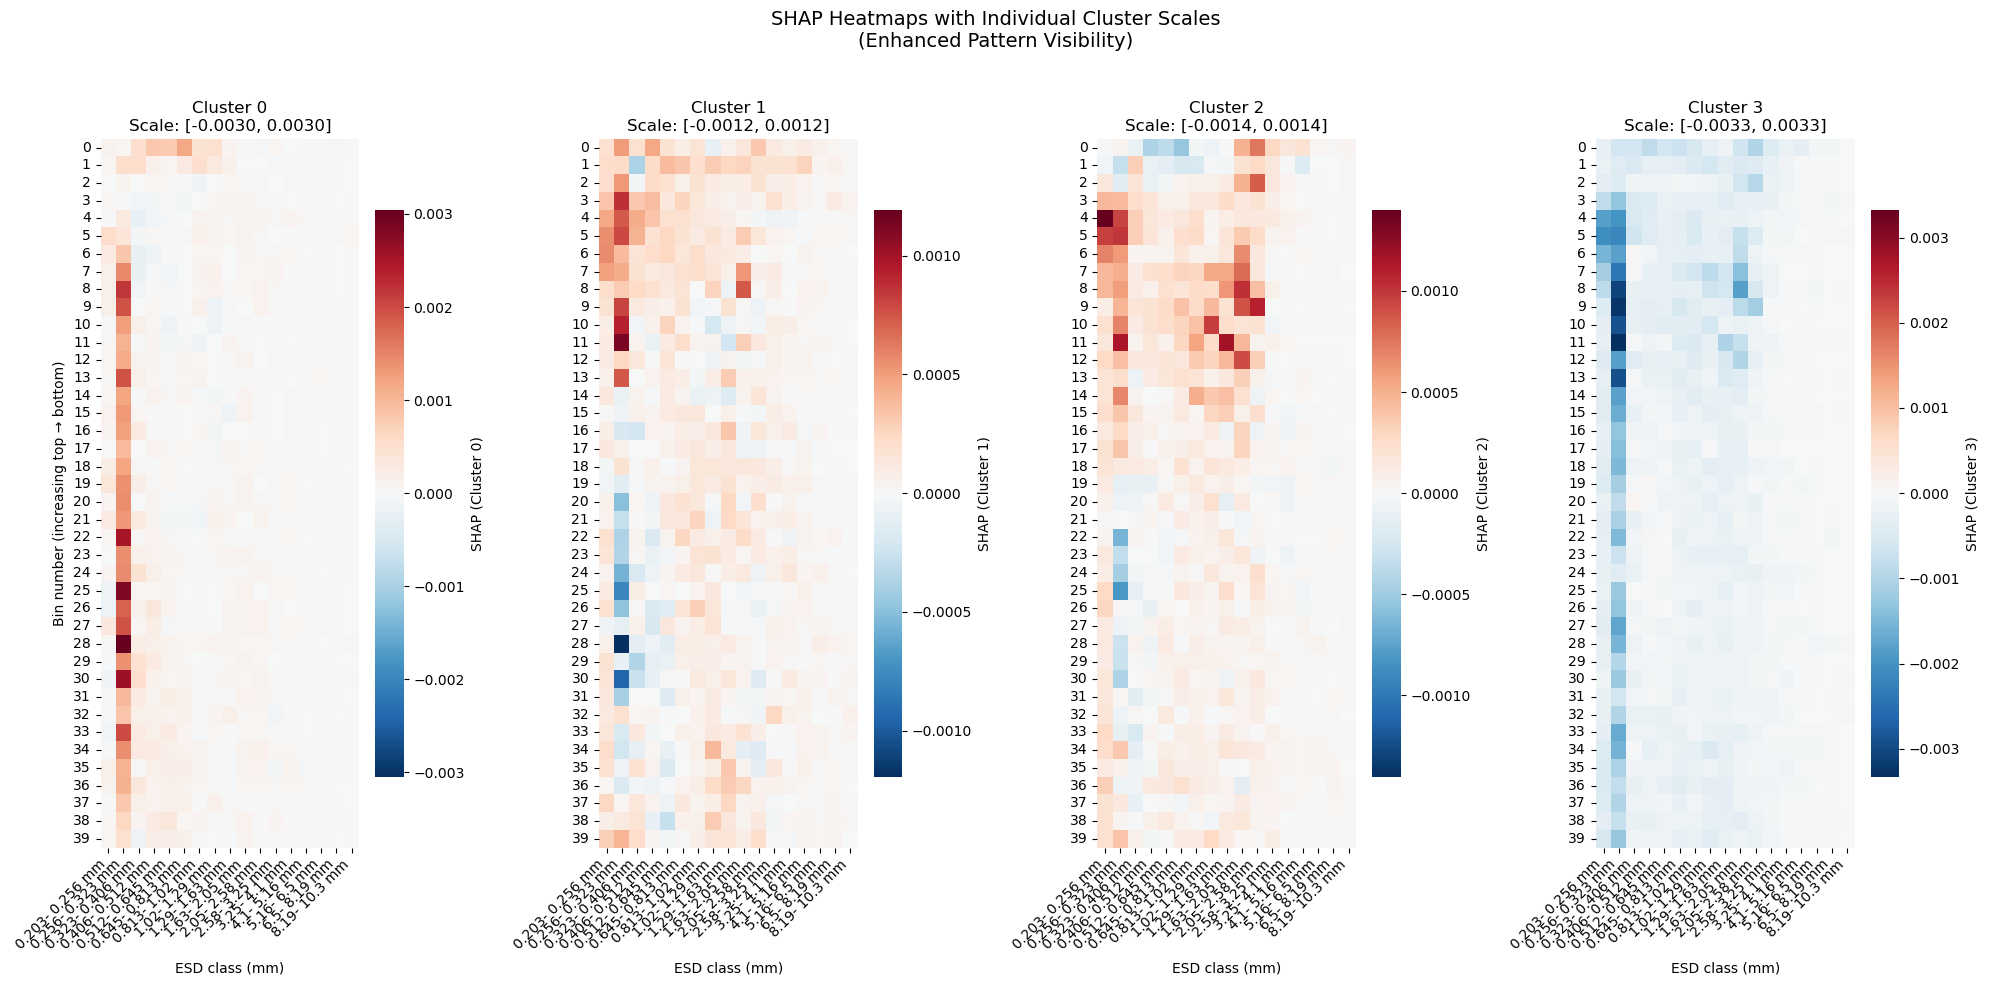


📊 Individual cluster scales:
  Cluster 0: [-0.003047, 0.003047] (range: 0.006093)
  Cluster 1: [-0.001195, 0.001195] (range: 0.002389)
  Cluster 2: [-0.001402, 0.001402] (range: 0.002805)
  Cluster 3: [-0.003329, 0.003329] (range: 0.006657)
✅ Enhanced heatmaps created!
📊 Each cluster now has its own color scale for maximum pattern visibility
🔍 Patterns should be much clearer now!


In [45]:
"""
Plot class-specific ESD×bin feature-importance heatmaps with SHAP color scale
(blue for negative, red for positive) and highlight cells above a given importance threshold. 

Usage examples: 

# From SHAP: 
pivots = plot_class_heatmaps_from_shap(
    shap_values=shap_values,
    X_test_sample=X_test_sample,
    n_classes=10,
    n_esd=17,
    n_bins=40,
    cmap="RdBu_r",  # SHAP color scale
    share_scale=True,
    center=0,  # center colormap at 0
    normalize=None,
    highlight_threshold=0.002,
    highlight_edgecolor="black",
    highlight_linewidth=1.5,
)
"""
from typing import Optional, Tuple, Dict, List, Any
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Regex to capture ESD range and bin number at the end of the feature name
_FEATURE_RE = re.compile(
    r"\(ESD\s*:\s*([0-9]*\.?[0-9]+)\s*-\s*([0-9]*\.?[0-9]+)\s*mm\).*_bin\s*([0-9]+)\s*$",
    flags=re.IGNORECASE,
)


def _parse_feature_name(fname: str) -> Tuple[Optional[float], Optional[float], Optional[int], Optional[str]]:
    """Return (esd_min, esd_max, bin_idx, esd_label) or (None, None, None, None)."""
    if not isinstance(fname, str):
        return (None, None, None, None)
    m = _FEATURE_RE.search(fname)
    if not m:
        return (None, None, None, None)
    esd_min = float(m.group(1))
    esd_max = float(m.group(2))
    bin_idx = int(m.group(3))
    esd_label = f"{esd_min: g}-{esd_max: g} mm"
    return (esd_min, esd_max, bin_idx, esd_label)


def _make_grid_index_and_cols(feature_names: List[str], n_esd: int, n_bins: int, esd_sort_by: str = "min"):
    """From feature names, get ordered esd_labels and bin_index list (0..n_bins-1)."""
    parsed = [_parse_feature_name(f) for f in feature_names]
    esd_info = {}
    bins_set = set()
    for esd_min, esd_max, bin_idx, esd_label in parsed:
        if esd_label is None:
            continue
        esd_info[esd_label] = (esd_min, esd_max)
        bins_set.add(bin_idx)
    if not esd_info:
        raise ValueError("No ESD-labeled features were parsed from feature_names.")

    esd_df = pd.DataFrame(
        [
            {"esd_label": k, "esd_min": v[0], "esd_max": v[1]}
            for k, v in esd_info.items()
        ]
    )

    if esd_sort_by == "min":
        esd_df = esd_df.sort_values("esd_min")
    elif esd_sort_by == "mid":
        esd_df["esd_mid"] = (esd_df["esd_min"] + esd_df["esd_max"]) / 2.0
        esd_df = esd_df.sort_values("esd_mid")
    else:
        raise ValueError("esd_sort_by must be 'min' or 'mid'")

    esd_order = esd_df["esd_label"].tolist()
    if len(esd_order) != n_esd:
        warnings.warn(f"Parsed {len(esd_order)} ESD classes but expected {n_esd}. Proceeding with parsed classes.")

    bin_order = list(range(n_bins))
    return esd_order, bin_order


def _build_pivot_from_feature_importances(
    feature_names: List[str],
    importances: np.ndarray,
    esd_order: List[str],
    bin_order:  List[int],
    feature_col_name: str = "Feature",
    importance_col_name: str = "Importance",
    fill_value: Optional[float] = np.nan,
) -> pd.DataFrame:
    """
    Build pivot (index=bins, columns=esd_label) from raw arrays.
    """
    if len(feature_names) != len(importances):
        raise ValueError("feature_names and importances must have the same length")

    df = pd.DataFrame({feature_col_name: feature_names, importance_col_name: importances})
    parsed = df[feature_col_name].apply(_parse_feature_name)
    df["esd_min"] = parsed.apply(lambda x: x[0])
    df["esd_max"] = parsed.apply(lambda x: x[1])
    df["bin"] = parsed.apply(lambda x: x[2])
    df["esd_label"] = parsed.apply(lambda x: x[3])

    n_total = len(df)
    n_parsed = df["esd_label"].notna().sum()
    if n_parsed != n_total:
        warnings.warn(f"{n_total - n_parsed} feature(s) couldn't be parsed and will be ignored in the grid.")
    df = df.loc[df["esd_label"].notna()].copy()

    pivot = df.pivot_table(index="bin", columns="esd_label", values=importance_col_name, aggfunc="mean")
    pivot = pivot.reindex(index=bin_order, columns=esd_order)

    if fill_value is not None:
        pivot = pivot.fillna(fill_value)

    return pivot


def _compute_class_importances_from_shap(
    shap_values: Any, 
    feature_names: List[str],
    use_mean_shap: bool = False  # NEW: option to use mean SHAP instead of mean |SHAP|
) -> np.ndarray:
    """
    Returns ndarray shape (n_classes, n_features) with: 
    - mean(shap) per class per feature if use_mean_shap=True (preserves sign)
    - mean(|shap|) per class per feature if use_mean_shap=False (magnitude only)
    """
    arr = np.array(shap_values)
    if isinstance(shap_values, list):
        try:
            arr = np.stack(shap_values, axis=2)
        except Exception as e:
            raise ValueError("Could not stack shap_values list:  " + str(e))

    if arr.ndim != 3:
        raise ValueError("shap_values must be 3D (n_samples, n_features, n_classes)")

    n_samples, n_features, n_classes = arr.shape
    
    if use_mean_shap: 
        # Mean SHAP (preserves positive/negative)
        mean_shap = arr.mean(axis=0)  # (n_features, n_classes)
        class_importances = mean_shap.T  # (n_classes, n_features)
    else:
        # Mean absolute SHAP (magnitude only)
        abs_arr = np.abs(arr)
        mean_abs = abs_arr.mean(axis=0)
        class_importances = mean_abs.T
    
    return class_importances


def plot_class_heatmaps_from_array(
    class_importances: np.ndarray,
    feature_names: List[str],
    n_classes: int,
    n_esd: int = 17,
    n_bins: int = 40,
    esd_sort_by: str = "min",
    fill_value: Optional[float] = np.nan,
    cmap: str = "RdBu_r",
    figsize_per_plot: Tuple[float, float] = (3.5, 8),
    share_scale: bool = False,  # CHANGED: Default to False for individual scaling
    center: float = 0.0,
    normalize: Optional[str] = None,
    highlight_threshold: Optional[float] = None,
    highlight_edgecolor: str = "black",
    highlight_linewidth:  float = 2.0,
    suptitle: Optional[str] = None,
    individual_scales: bool = True,  # NEW: Force individual scales per cluster
) -> Dict[int, pd.DataFrame]:
    """
    Plot heatmaps with individual color scales per cluster for enhanced pattern visibility.
    """
    class_importances = np.asarray(class_importances)
    if class_importances.ndim != 2:
        raise ValueError("class_importances must be 2D array (n_classes, n_features)")
    if class_importances.shape[1] != len(feature_names):
        warnings.warn("Number of features in class_importances does not match feature_names length.")

    esd_order, bin_order = _make_grid_index_and_cols(feature_names, n_esd, n_bins, esd_sort_by=esd_sort_by)

    pivots:  Dict[int, pd.DataFrame] = {}
    for cls_idx in range(min(n_classes, class_importances.shape[0])):
        imp = class_importances[cls_idx, :]
        pivot = _build_pivot_from_feature_importances(
            feature_names, imp, esd_order, bin_order, fill_value=fill_value
        )
        pivots[cls_idx] = pivot

    if normalize is not None:
        for k, piv in pivots.items():
            if normalize == "col":
                with np.errstate(divide="ignore", invalid="ignore"):
                    piv = piv.div(piv.sum(axis=0), axis=1)
            elif normalize == "row":
                with np.errstate(divide="ignore", invalid="ignore"):
                    piv = piv.div(piv.sum(axis=1), axis=0)
            elif normalize == "global":
                maxv = np.nanmax(np.abs(piv. values. astype(float)))
                if maxv != 0 and not np.isnan(maxv):
                    piv = piv / maxv
            else:
                raise ValueError("normalize must be one of {None, 'col', 'row', 'global'}")
            pivots[k] = piv

    # CHANGED: Always use individual scales when individual_scales=True
    if individual_scales or not share_scale:
        # Each cluster gets its own scale
        cluster_scales = {}
        for cls_idx, pivot in pivots.items():
            finite_vals = pivot.values[np.isfinite(pivot.values)]
            if finite_vals.size > 0:
                abs_max = max(abs(finite_vals. min() - center), abs(finite_vals.max() - center))
                cluster_scales[cls_idx] = (center - abs_max, center + abs_max)
            else:
                cluster_scales[cls_idx] = (None, None)
    else:
        # Shared scale (original behavior)
        all_vals = np.concatenate([p.values. ravel() for p in pivots.values()])
        finite = all_vals[np.isfinite(all_vals)]
        if finite.size:
            abs_max = max(abs(finite.min() - center), abs(finite.max() - center))
            shared_scale = (center - abs_max, center + abs_max)
        else:
            shared_scale = (None, None)
        cluster_scales = {cls_idx: shared_scale for cls_idx in pivots.keys()}

    n_plots = len(pivots)
    fig_w = max(1.0, figsize_per_plot[0] * n_plots)
    fig_h = max(1.0, figsize_per_plot[1])
    fig, axes = plt. subplots(nrows=1, ncols=n_plots, figsize=(fig_w, fig_h), squeeze=False)
    axes_row = axes[0]

    for idx, cls_idx in enumerate(sorted(pivots.keys())):
        ax = axes_row[idx]
        pivot = pivots[cls_idx]
        
        # Use individual scale for this cluster
        vmin, vmax = cluster_scales[cls_idx]
        
        # Create heatmap with cluster-specific scale
        sns.heatmap(
            pivot, 
            ax=ax, 
            cmap=cmap, 
            center=center,
            cbar=True,  # CHANGED: Show colorbar for each cluster
            vmin=vmin, 
            vmax=vmax,
            annot=False, 
            linewidths=0.0, 
            linecolor="white",
            cbar_kws={
                'label': f'SHAP (Cluster {cls_idx})',
                'shrink': 0.8
            }
        )
        
        # CHANGED: Enhanced title with scale info
        scale_info = f"[{vmin:.4f}, {vmax:.4f}]" if vmin is not None else "[No data]"
        ax.set_title(f"Cluster {cls_idx}\nScale: {scale_info}", fontsize=12)
        
        ax.set_xlabel("ESD class (mm)")
        if idx == 0:
            ax.set_ylabel("Bin number (increasing top → bottom)")
        else:
            ax.set_ylabel("")
        ax.set_xticklabels(ax. get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        # Highlight cells - use cluster-specific threshold if provided
        if highlight_threshold is not None:
            # Option:  Use relative threshold based on cluster's own scale
            if individual_scales and vmax is not None:
                # Use percentage of cluster's range
                cluster_threshold = highlight_threshold * abs(vmax - center)
            else:
                # Use absolute threshold
                cluster_threshold = highlight_threshold
                
            mask = (np.abs(pivot.values) > cluster_threshold) & np.isfinite(pivot.values)
            
            if mask.any():
                rows, cols = np.where(mask)
                for r_i, c_i in zip(rows, cols):
                    rect = Rectangle(
                        (c_i, r_i), 1, 1, fill=False, edgecolor=highlight_edgecolor,
                        linewidth=highlight_linewidth, clip_on=False
                    )
                    ax.add_patch(rect)

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96] if suptitle else None)
    plt.show()

    # Print scale information for reference
    print("\n📊 Individual cluster scales:")
    for cls_idx in sorted(pivots.keys()):
        vmin, vmax = cluster_scales[cls_idx]
        if vmin is not None: 
            range_val = vmax - vmin
            print(f"  Cluster {cls_idx}: [{vmin:.6f}, {vmax:.6f}] (range: {range_val:.6f})")
        else:
            print(f"  Cluster {cls_idx}: No finite values")

    return pivots

def plot_class_heatmaps_from_shap(
    shap_values: Any,
    X_test_sample: pd.DataFrame,
    n_classes: int = 10,
    n_esd: int = 17,
    n_bins: int = 40,
    esd_sort_by: str = "min",
    fill_value: Optional[float] = np.nan,
    cmap: str = "RdBu_r",  
    figsize_per_plot:  Tuple[float, float] = (3.5, 8),
    share_scale: bool = False,  # CHANGED: Default to individual scales
    center: float = 0.0,
    use_mean_shap: bool = True,
    normalize: Optional[str] = None,
    highlight_threshold:  Optional[float] = None,
    highlight_edgecolor: str = "black",
    highlight_linewidth: float = 2.0,
    suptitle:  Optional[str] = None,
    individual_scales: bool = True,  # NEW: Enable individual scaling
) -> Dict[int, pd.DataFrame]:  
    """
    Enhanced version with individual color scales per cluster for better pattern visibility.
    """
    feature_names = list(X_test_sample.columns)
    class_importances = _compute_class_importances_from_shap(
        shap_values, feature_names, use_mean_shap=use_mean_shap
    )
    
    if class_importances.shape[0] != n_classes:
        warnings.warn(f"Computed {class_importances.shape[0]} classes from SHAP but expected n_classes={n_classes}.")

    return plot_class_heatmaps_from_array(
        class_importances=class_importances,
        feature_names=feature_names,
        n_classes=class_importances.shape[0],
        n_esd=n_esd,
        n_bins=n_bins,
        esd_sort_by=esd_sort_by,
        fill_value=fill_value,
        cmap=cmap,
        figsize_per_plot=figsize_per_plot,
        share_scale=share_scale,
        center=center,
        normalize=normalize,
        highlight_threshold=highlight_threshold,
        highlight_edgecolor=highlight_edgecolor,
        highlight_linewidth=highlight_linewidth,
        suptitle=suptitle,
        individual_scales=individual_scales,
    )

# Enhanced usage with adaptive threshold
def create_enhanced_cluster_heatmaps(shap_values, X_test_sample):
    """Create heatmaps with individual scales and adaptive highlighting"""
    
    # Compute per-cluster thresholds
    class_importances = _compute_class_importances_from_shap(
        shap_values, list(X_test_sample.columns), use_mean_shap=True
    )
    
    # Use relative threshold (e.g., top 10% within each cluster)
    relative_threshold = None  # Top 10% of each cluster's range
    
    print("🎨 Creating enhanced heatmaps with individual cluster scales...")
    
    pivots = plot_class_heatmaps_from_shap(
        shap_values=shap_values, 
        X_test_sample=X_test_sample, 
        n_classes=4,  # Assuming 4 clusters
        n_esd=17, 
        n_bins=40, 
        highlight_threshold=relative_threshold,  # Relative to each cluster's scale
        highlight_linewidth=0.5,
        cmap="RdBu_r",
        center=0.0,
        use_mean_shap=True,
        share_scale=False,  # Individual scales
        individual_scales=True,  # Enhanced individual scaling
        normalize=None,
        figsize_per_plot=(5, 10),
        suptitle="SHAP Heatmaps with Individual Cluster Scales\n(Enhanced Pattern Visibility)"
    )
    
    return pivots

# Usage example: 
if __name__ == "__main__":
    # Enhanced version with individual scales
    print("🚀 Creating enhanced heatmaps with individual cluster color scales...")
    
    enhanced_pivots = create_enhanced_cluster_heatmaps(shap_values, X_test_sample)
    
    print("✅ Enhanced heatmaps created!")
    print("📊 Each cluster now has its own color scale for maximum pattern visibility")
    print("🔍 Patterns should be much clearer now!")